Extracting EDF parameters from ../data/Subject00_1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 90999  =      0.000 ...   181.998 secs...
Extracting EDF parameters from ../data/Subject00_2.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 30999  =      0.000 ...    61.998 secs...
<RawEDF | Subject00_1.edf, 21 x 91000 (182.0 s), ~14.6 MiB, data loaded>
<RawEDF | Subject00_2.edf, 21 x 31000 (62.0 s), ~5.0 MiB, data loaded>
Channels: ['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']
Sampling rate: 500.0
['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1']


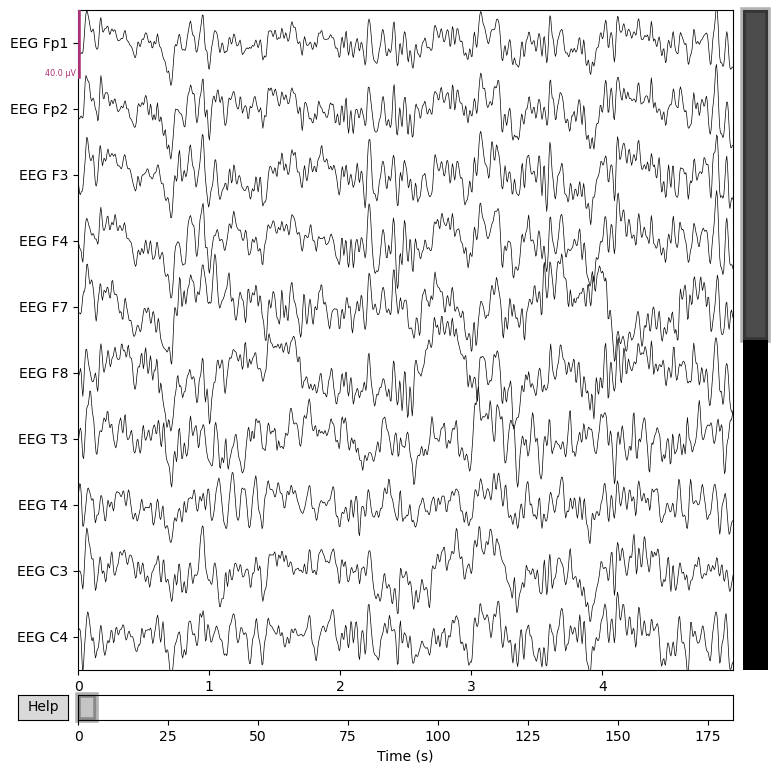

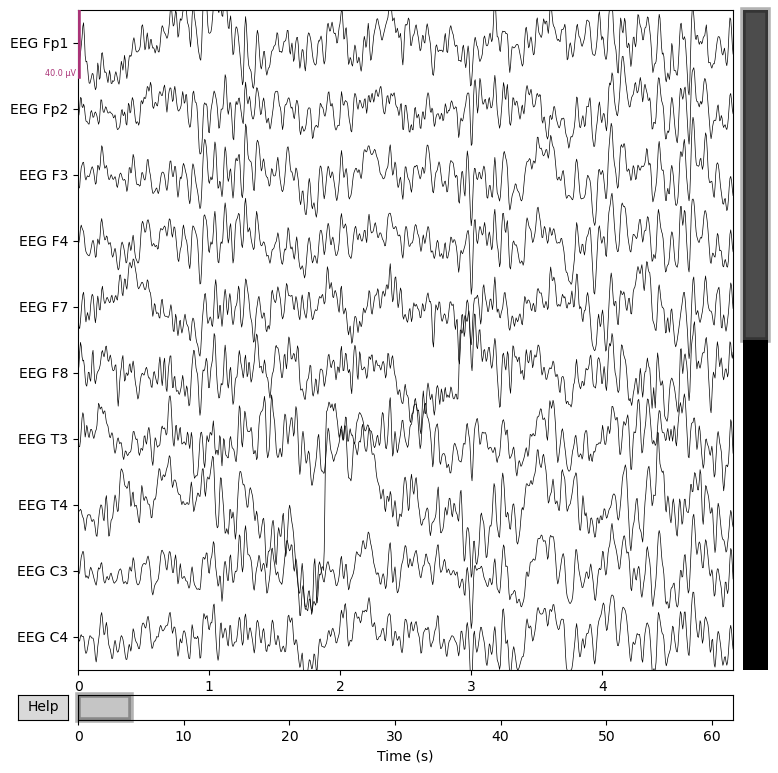

Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


/var/folders/6c/g675_x4d5v5_mvns7b2x90gc0000gn/T/ipykernel_65443/3167291097.py:27: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  rest_psd.plot()
/opt/anaconda3/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
/var/folders/6c/g675_x4d5v5_mvns7b2x90gc0000gn/T/ipykernel_65443/3167291097.py:28: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  task_psd.plot()
/opt/anaconda3/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


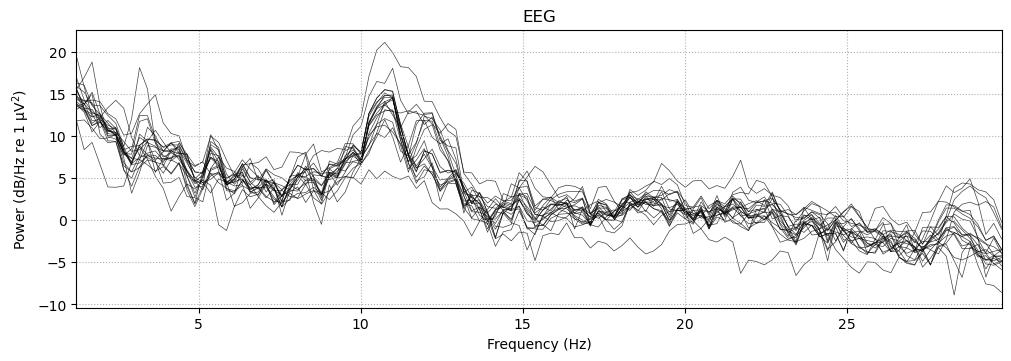

In [55]:
import mne

# Load one baseline file
raw_rest = mne.io.read_raw_edf("../data/Subject00_1.edf", preload=True)

# Load one task file
raw_task = mne.io.read_raw_edf("../data/Subject00_2.edf", preload=True)

print(raw_rest)
print(raw_task)

print("Channels:", raw_rest.ch_names)
print("Sampling rate:", raw_rest.info["sfreq"])

# Drop non-EEG channels (specifically ECG)
drop_channels = [ch for ch in raw_rest.ch_names if "ECG" in ch]
raw_rest = raw_rest.copy().drop_channels(drop_channels)
raw_task = raw_task.copy().drop_channels(drop_channels)

print(raw_rest.ch_names)
# Quick look at a few seconds of signal
raw_rest.plot(duration=5, n_channels=10)
raw_task.plot(duration=5, n_channels=10)

rest_psd = raw_rest.compute_psd(method="welch", fmin=1, fmax=30)
task_psd = raw_task.compute_psd(method="welch", fmin=1, fmax=30)
rest_psd.plot()
task_psd.plot()

#raw information and plot of first patient data

In [56]:
import numpy as np

bands = {
    "theta": (4, 7),
    "alpha": (8, 12),
    "beta": (13, 30),
}

def get_bandpower(raw):
    psd = raw.compute_psd(method="welch", fmin=1, fmax=30)
    psds, freqs = psd.get_data(return_freqs=True)

    band_means = {}

    for band, (fmin, fmax) in bands.items():
        idx = (freqs >= fmin) & (freqs <= fmax)
        band_power = psds[:, idx].mean()  # average across channels + freq
        band_means[band] = band_power

    return band_means

rest_power = get_bandpower(raw_rest)
task_power = get_bandpower(raw_task)

print("REST:", rest_power)
print("TASK:", task_power)

#average accross all channels and frequencies in each band for rest and task, then compare (still one patient)

Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
REST: {'theta': np.float64(3.47764225562828e-12), 'alpha': np.float64(1.2735059464620941e-11), 'beta': np.float64(1.1026802667252614e-12)}
TASK: {'theta': np.float64(3.953001151634079e-12), 'alpha': np.float64(1.0575499093307783e-11), 'beta': np.float64(1.163007268942607e-12)}


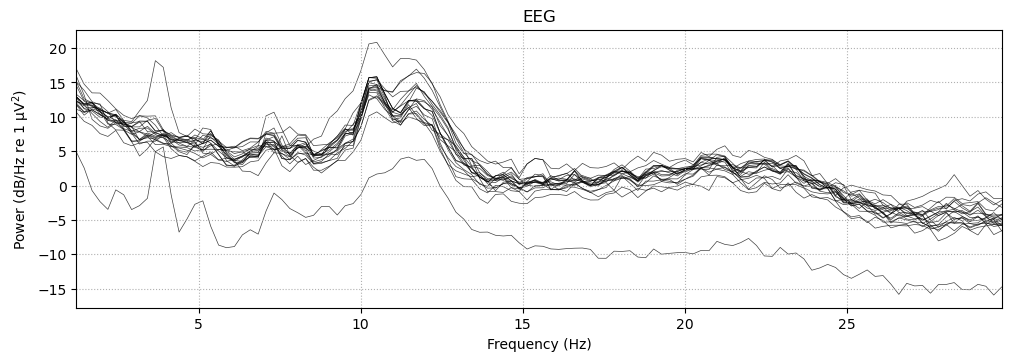

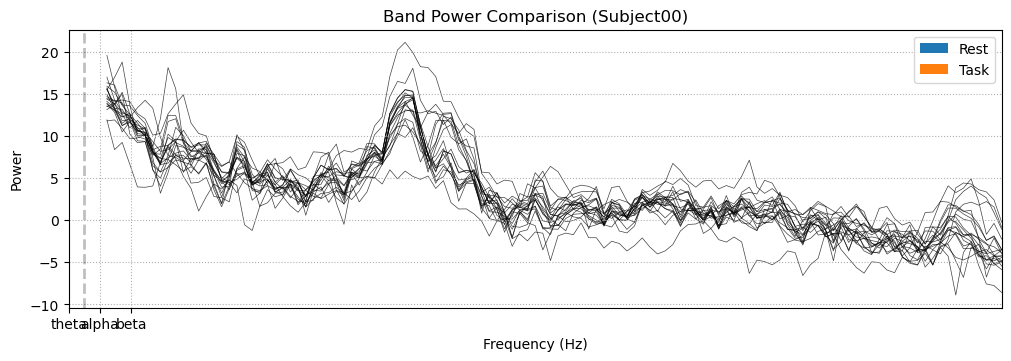

In [57]:
import matplotlib.pyplot as plt

labels = list(rest_power.keys())
rest_vals = list(rest_power.values())
task_vals = list(task_power.values())

x = np.arange(len(labels))

plt.bar(x - 0.2, rest_vals, width=0.4, label="Rest")
plt.bar(x + 0.2, task_vals, width=0.4, label="Task")

plt.xticks(x, labels)
plt.ylabel("Power")
plt.title("Band Power Comparison (Subject00)")
plt.legend()
plt.show()

#Showing results for one patient normalized values

In [58]:
import os
import re
import numpy as np
import pandas as pd
import mne

DATA_DIR = "../data"

bands = {
    "theta": (4, 7),
    "alpha": (8, 12),
    "beta": (13, 30),
}

def parse_filename(filename):
    """
    Extract subject ID and condition from filenames like:
    Subject00_1.edf, Subject00_2.edf
    Returns:
        subject_id (int), condition_num (int), label (int)
    label mapping:
        0 = rest/baseline (_1)
        1 = task (_2)
    """
    match = re.match(r"Subject(\d+)_(\d)\.edf$", filename)
    if not match:
        return None, None, None

    subject_id = int(match.group(1))
    condition_num = int(match.group(2))
    label = 0 if condition_num == 1 else 1
    return subject_id, condition_num, label

def load_and_clean_edf(filepath):
    """
    Load EDF and drop non-EEG channels.
    """
    raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)

    # Drop ECG if present
    drop_channels = [ch for ch in raw.ch_names if "ECG" in ch.upper()]
    if drop_channels:
        raw = raw.copy().drop_channels(drop_channels)

    return raw

def extract_bandpower_features(raw, bands):
    """
    Compute mean band power across all remaining channels.
    Returns a dict with theta/alpha/beta values.
    """
    psd = raw.compute_psd(method="welch", fmin=1, fmax=30, verbose=False)
    psds, freqs = psd.get_data(return_freqs=True)

    features = {}
    for band_name, (fmin, fmax) in bands.items():
        idx = (freqs >= fmin) & (freqs <= fmax)
        band_power = psds[:, idx].mean()  # average across channels + freq
        features[band_name] = band_power

    return features

rows = []

for filename in sorted(os.listdir(DATA_DIR)):
    if not filename.endswith(".edf"):
        continue

    subject_id, condition_num, label = parse_filename(filename)
    if subject_id is None:
        print(f"Skipping unexpected filename: {filename}")
        continue

    filepath = os.path.join(DATA_DIR, filename)

    raw = load_and_clean_edf(filepath)
    features = extract_bandpower_features(raw, bands)

    row = {
        "filename": filename,
        "subject": subject_id,
        "condition_num": condition_num,
        "condition": "rest" if label == 0 else "task",
        "label": label,
        **features,
    }
    rows.append(row)

df = pd.DataFrame(rows).sort_values(["subject", "condition_num"]).reset_index(drop=True)
print(df.shape)
print(df["condition"].value_counts())
df.head(10)


#loading in all of the patients, extracting relevant features, creating a df for analysis

(72, 8)
condition
rest    36
task    36
Name: count, dtype: int64


,filename,subject,condition_num,condition,label,theta,alpha,beta
0,Subject00_1.edf,0,1,rest,0,3.477642e-12,1.273506e-11,1.102680e-12
1,Subject00_2.edf,0,2,task,1,3.953001e-12,1.057550e-11,1.163007e-12
2,Subject01_1.edf,1,1,rest,0,3.086965e-12,3.940568e-12,9.765177e-13
3,Subject01_2.edf,1,2,task,1,5.386034e-12,3.876351e-12,8.985672e-13
4,Subject02_1.edf,2,1,rest,0,3.518997e-12,7.591754e-12,1.252376e-12
5,Subject02_2.edf,2,2,task,1,2.281701e-12,6.066956e-12,1.269864e-12
6,Subject03_1.edf,3,1,rest,0,4.132386e-12,1.365683e-11,6.583427e-13
7,Subject03_2.edf,3,2,task,1,2.508481e-12,3.749208e-12,3.311970e-13
8,Subject04_1.edf,4,1,rest,0,7.986376e-12,1.028531e-11,1.547634e-12
9,Subject04_2.edf,4,2,task,1,7.806888e-12,6.195612e-12,1.363944e-12


In [59]:
df.groupby("condition")[["theta", "alpha", "beta"]].mean()
#mean vals for each band in rest vs task conditions

,theta,alpha,beta
condition,,,
rest,3.569988e-12,8.396822e-12,6.930260e-13
task,3.494053e-12,5.482884e-12,6.028820e-13


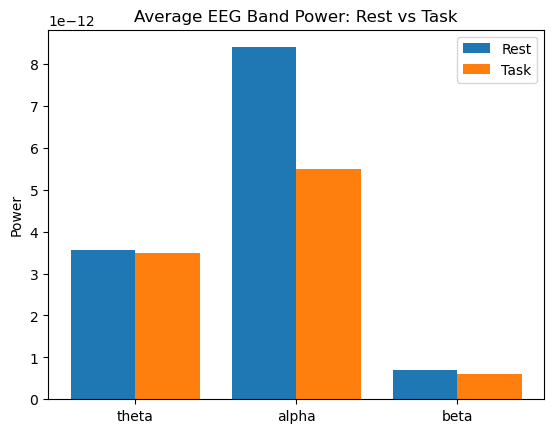

In [60]:
import matplotlib.pyplot as plt
import numpy as np

means = df.groupby("condition")[["theta", "alpha", "beta"]].mean()

labels = ["theta", "alpha", "beta"]
rest_vals = means.loc["rest"].values
task_vals = means.loc["task"].values

x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, rest_vals, width=0.4, label="Rest")
plt.bar(x + 0.2, task_vals, width=0.4, label="Task")

plt.xticks(x, labels)
plt.ylabel("Power")
plt.title("Average EEG Band Power: Rest vs Task")
plt.legend()

plt.show()

#plot of normalized values for rest vs task across all patients

In [61]:
# separate rest and task
rest_df = df[df["condition"] == "rest"].set_index("subject")
task_df = df[df["condition"] == "task"].set_index("subject")

# align by subject
common_subjects = rest_df.index.intersection(task_df.index)

rest_df = rest_df.loc[common_subjects]
task_df = task_df.loc[common_subjects]

# compute differences
diff_df = task_df[["theta", "alpha", "beta"]] - rest_df[["theta", "alpha", "beta"]]

import numpy as np

def bootstrap_ci(data, n_boot=1000, ci=95):
    boot_means = []

    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)

    return np.mean(data), lower, upper

for band in ["theta", "alpha", "beta"]:
    mean_diff, lower, upper = bootstrap_ci(diff_df[band].values)

    print(f"{band.upper()}:")
    print(f"  Mean diff = {mean_diff:.3e}")
    print(f"  95% CI = [{lower:.3e}, {upper:.3e}]\n")

#NOTE CIs do not contain 0 besides Theta, meaning alpha and beta are consistently lower in task vs rest

THETA:
  Mean diff = -7.593e-14
  95% CI = [-4.295e-13, 2.884e-13]

ALPHA:
  Mean diff = -2.914e-12
  95% CI = [-4.209e-12, -1.459e-12]

BETA:
  Mean diff = -9.014e-14
  95% CI = [-1.308e-13, -5.402e-14]



In [62]:
#build classification model

X = df[["theta", "alpha", "beta"]].values
y = df["label"].values

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = make_pipeline(StandardScaler(), LogisticRegression())
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6

Confusion Matrix:
 [[4 4]
 [2 5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.50      0.57         8
           1       0.56      0.71      0.62         7

    accuracy                           0.60        15
   macro avg       0.61      0.61      0.60        15
weighted avg       0.61      0.60      0.60        15



In [ ]:
import os
import re
import pandas as pd
import mne

DATA_DIR = "../data"

bands = {
    "theta": (4, 7),
    "alpha": (8, 12),
    "beta": (13, 30),
}

def parse_filename(filename):
    match = re.match(r"Subject(\d+)_(\d)\.edf$", filename)
    if not match:
        return None, None, None

    subject_id = int(match.group(1))
    condition_num = int(match.group(2))
    label = 0 if condition_num == 1 else 1
    return subject_id, condition_num, label

def load_and_clean_edf(filepath):
    raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
    drop_channels = [ch for ch in raw.ch_names if "ECG" in ch.upper()]
    if drop_channels:
        raw = raw.copy().drop_channels(drop_channels)
    return raw

def extract_channel_bandpower_features(raw, bands):
    psd = raw.compute_psd(method="welch", fmin=1, fmax=30, verbose=False)
    psds, freqs = psd.get_data(return_freqs=True)

    features = {}
    for band_name, (fmin, fmax) in bands.items():
        idx = (freqs >= fmin) & (freqs <= fmax)
        band_power = psds[:, idx].mean(axis=1)  # one value per channel

        for i, ch in enumerate(raw.ch_names):
            clean_ch = ch.replace(" ", "_").replace("-", "_")
            features[f"{band_name}_{clean_ch}"] = float(band_power[i])

    return features

rows = []

for filename in sorted(os.listdir(DATA_DIR)):
    if not filename.endswith(".edf"):
        continue

    subject_id, condition_num, label = parse_filename(filename)
    if subject_id is None:
        continue

    filepath = os.path.join(DATA_DIR, filename)
    raw = load_and_clean_edf(filepath)
    features = extract_channel_bandpower_features(raw, bands)

    row = {
        "filename": filename,
        "subject": subject_id,
        "condition_num": condition_num,
        "condition": "rest" if label == 0 else "task",
        "label": label,
        **features
    }
    rows.append(row)

df_channels = pd.DataFrame(rows).sort_values(
    ["subject", "condition_num"]
).reset_index(drop=True)

print(df_channels.shape)
print(df_channels.head())

#creating a new df with band power features for each channel, instead of averaging across channels, to see if we can get better classification results by preserving spatial info

(72, 65)
          filename  subject  condition_num condition  label  theta_EEG_Fp1  \
0  Subject00_1.edf        0              1      rest      0   2.194262e-12   
1  Subject00_2.edf        0              2      task      1   4.468156e-12   
2  Subject01_1.edf        1              1      rest      0   2.809654e-12   
3  Subject01_2.edf        1              2      task      1   8.343012e-12   
4  Subject02_1.edf        2              1      rest      0   1.796488e-12   

   theta_EEG_Fp2  theta_EEG_F3  theta_EEG_F4  theta_EEG_F7  ...   beta_EEG_T5  \
0   2.891131e-12  3.755283e-12  4.498575e-12  3.687324e-12  ...  7.946518e-13   
1   3.484211e-12  4.334535e-12  4.613979e-12  3.733053e-12  ...  1.232416e-12   
2   3.479402e-12  3.895575e-12  4.290236e-12  2.117865e-12  ...  6.136951e-13   
3   6.535857e-12  7.189348e-12  6.463418e-12  5.567820e-12  ...  5.705021e-13   
4   8.467313e-12  4.078152e-12  2.968013e-12  1.558062e-12  ...  7.172591e-13   

    beta_EEG_T6   beta_EEG_P3   bet

In [67]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

meta_cols = ["filename", "subject", "condition_num", "condition", "label"]
feature_cols = [c for c in df_channels.columns if c not in meta_cols]

print("Number of feature columns:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])

X = df_channels[feature_cols].values
y = df_channels["label"].values
groups = df_channels["subject"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Number of feature columns: 60
First 10 feature columns: ['theta_EEG_Fp1', 'theta_EEG_Fp2', 'theta_EEG_F3', 'theta_EEG_F4', 'theta_EEG_F7', 'theta_EEG_F8', 'theta_EEG_T3', 'theta_EEG_T4', 'theta_EEG_C3', 'theta_EEG_C4']
Accuracy: 0.625

Confusion Matrix:
 [[3 5]
 [1 7]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.38      0.50         8
           1       0.58      0.88      0.70         8

    accuracy                           0.62        16
   macro avg       0.67      0.62      0.60        16
weighted avg       0.67      0.62      0.60        16



In [68]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score

logo = LeaveOneGroupOut()

scores = cross_val_score(
    model,
    X,
    y,
    cv=logo.split(X, y, groups=groups)
)

print("LOSO accuracies:", scores)
print("Mean LOSO accuracy:", scores.mean())

LOSO accuracies: [0.5 0.5 0.5 1.  1.  1.  0.5 1.  0.5 0.5 1.  0.  0.  0.5 0.5 1.  1.  0.5
 0.5 1.  1.  0.  0.5 1.  0.5 1.  0.5 0.5 1.  0.5 1.  1.  0.5 0.5 0.5 0.5]
Mean LOSO accuracy: 0.6527777777777778


In [ ]:
meta = pd.read_csv("../data/subject-info.csv")
meta["subject"] = meta["Subject"].str.extract(r"(\d+)").astype(int)
df_channels_strength = df_channels.merge(
    meta,
    on="subject",
    how="left"
)

df_strong = df_channels_strength[df_channels_strength["Count quality"] == 1].copy()
df_weak = df_channels_strength[df_channels_strength["Count quality"] == 0].copy()

from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

meta_cols = [
    "filename", "subject", "condition_num", "condition", "label",
    "Subject", "Age", "Gender", "Recording year",
    "Number of subtractions", "Count quality"
]

strong_feature_cols = [c for c in df_strong.columns if c not in meta_cols]
weak_feature_cols = [c for c in df_weak.columns if c not in meta_cols]

X = df_strong[feature_cols].values
y = df_strong["label"].values
groups = df_strong["subject"].values

X_w = df_weak[feature_cols].values
y_w = df_weak["label"].values
groups_w = df_weak["subject"].values

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

logo = LeaveOneGroupOut()

scores = cross_val_score(
    model,
    X,
    y,
    cv=logo.split(X, y, groups=groups)
)
scores_w = cross_val_score(
    model,
    X_w,
    y_w,
    cv=logo.split(X_w, y_w, groups=groups_w)
)
print("Strong group LOSO accuracies:", scores)
print("Mean LOSO accuracy (strong group):", scores.mean())
print("\n")
print("Weak group LOSO accuracies:", scores_w)
print("Mean LOSO accuracy (weak group):", scores_w.mean())

Strong group LOSO accuracies: [1.  0.5 0.5 1.  1.  0.5 0.5 0.  0.5 0.5 1.  1.  0.5 1.  0.5 0.5 1.  0.5
 0.5 1.  0.5 1.  0.5 0.5 0.5 0.5]
Mean LOSO accuracy (weak group): 0.6538461538461539


Weak group LOSO accuracies: [0.5 0.5 0.5 0.5 0.5 0.5 1.  0.5 1.  0.5]
Mean LOSO accuracy (weak group): 0.6


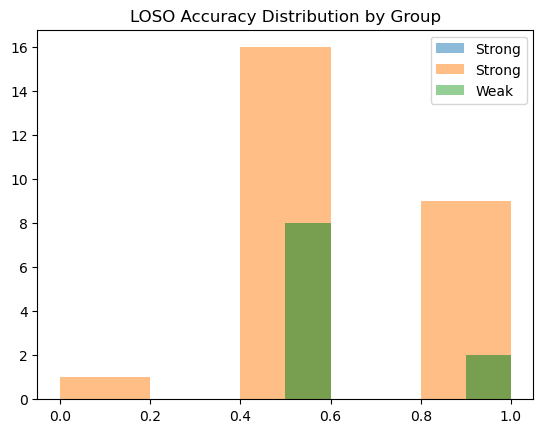

In [82]:
import matplotlib.pyplot as plt

plt.hist(scores, bins=5, alpha=0.5, label="Strong")
plt.hist(scores_w, bins=5, alpha=0.5, label="Weak")
plt.legend()
plt.title("LOSO Accuracy Distribution by Group")
plt.show()